# CE49X Lab 4: Istanbul Earthquake Risk Communication Dashboard
## Visualization for Decision-Makers

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

**Group Members:**
| Name | Student ID |
|------|------------|
| *(your name)* | *(your ID)* |
| *(partner's name)* | *(partner's ID)* |

## Background

Istanbul sits directly on the **North Anatolian Fault (NAF)**, one of the most active strike-slip faults in the world. The devastating 1999 Izmit earthquake (M7.6) ruptured a segment just 80 km east of the city, and seismologists have long warned that the next major rupture is expected beneath the Sea of Marmara — directly south of Istanbul.

The 2023 Kahramanmaras earthquake sequence (M7.8 + M7.5) demonstrated the catastrophic potential of large earthquakes in Turkey and renewed urgency around earthquake preparedness in Istanbul, a city of over 16 million people.

Effective **risk communication** is critical: decision-makers in municipal government need clear, honest, and actionable visualizations — not just raw data. A misleading colormap or a truncated axis can distort risk perception and lead to poor resource allocation.

> **Key Insight:** Visualization is not decoration — it is a critical tool for communicating risk to non-technical audiences. Every design choice (color, scale, annotation) shapes how decision-makers understand and act on data.

## Scenario

You have been hired as a **visualization consultant** for Istanbul's Disaster Coordination Center (AFAD Istanbul). Your task is to create a set of **publication-quality visualizations** for a risk communication report that will be presented to the **Istanbul Municipal Council** — a non-technical audience of elected officials who must decide how to allocate earthquake preparedness funding across Istanbul's districts.

Your visualizations must be:
- **Accurate** — no misleading scales, truncated axes, or rainbow colormaps
- **Clear** — interpretable by someone without a seismology background
- **Actionable** — each chart should support a specific decision or insight
- **Professional** — publication-ready with proper labels, titles, and annotations

## Data Requirements

You must collect **three categories** of real data. No data files are provided — you are responsible for sourcing, downloading, and documenting your data. For each dataset, record the **source URL**, **date accessed**, **how you obtained it**, and **number of records**.

### 1. Earthquake Catalog (required)

Historical earthquakes for the Marmara region. You need **at least 200 earthquakes** with year, latitude, longitude, depth, and magnitude.

Suggested sources:
- **AFAD Earthquake Department**: [deprem.afad.gov.tr](https://deprem.afad.gov.tr) — Turkey's official earthquake catalog, searchable by region/date/magnitude, downloadable as CSV
- **KOERI (Kandilli Observatory)**: [koeri.boun.edu.tr](http://www.koeri.boun.edu.tr) — Bogazici University's own seismology center
- **USGS Earthquake Catalog**: [earthquake.usgs.gov/earthquakes/search](https://earthquake.usgs.gov/earthquakes/search/) — global catalog, CSV export, filter by lat/lon bounding box (e.g., 40-41.5°N, 27-31°E for the Marmara region)

### 2. Building / Population Data (required)

Istanbul district-level data on buildings and/or population. You need data for **at least 10 Istanbul districts** with population and at least one building-related metric (age, type, or count).

Suggested sources:
- **TUIK (Turkish Statistical Institute)**: [data.tuik.gov.tr](https://data.tuik.gov.tr) — district-level population, building permits, construction statistics
- **IBB Open Data Portal**: [data.ibb.gov.tr](https://data.ibb.gov.tr) — Istanbul municipality datasets on buildings, infrastructure, demographics
- **Wikipedia / official district pages** — acceptable for population/area if properly cited

### 3. Seismic Hazard or Vulnerability Data (required)

Any dataset that allows spatial visualization of earthquake risk. You need spatial risk data covering Istanbul (grid, district-level, or at least 10 data points with coordinates).

Options include:
- **AFAD seismic hazard maps** — PGA (Peak Ground Acceleration) values or seismic zones for Istanbul
- **AFAD/IBB building damage estimates** — expected damage scenarios for a major Marmara earthquake
- **Soil classification maps** from IBB or academic papers
- **Any published risk study** with district-level or grid-level data (can be manually digitized from a figure if necessary)

## Deliverables Overview

| # | Title | Points | Key Techniques |
|---|-------|--------|----------------|
| D1 | Data Collection & Documentation | 10 | Data sourcing, Pandas loading, `df.head()`, `df.describe()` |
| D2 | Historical Seismicity Timeline | 15 | Scatter with variable size/color, colorbar, `annotate` |
| D3 | Magnitude-Frequency Analysis | 15 | Histogram + KDE, `axvline`, log-plot with linear fit |
| D4 | Building Vulnerability or Population Risk | 15 | Seaborn categorical plots, sorted charts, color encoding |
| D5 | Earthquake Hazard Visualization | 20 | `contourf`/scatter/heatmap, sequential colormap, annotations |
| D6 | Multi-Panel Risk Dashboard + Reflection | 25 | `GridSpec`, 3+ chart types, derived metric, `savefig`, written reflection |
| **Total** | | **100** | |

---
## Deliverable 1: Data Collection & Documentation (10 pts)

Load all three collected datasets into Pandas DataFrames. For **each** dataset:

1. **Document the source** — URL, date accessed, how you obtained the data (e.g., "downloaded CSV from USGS search interface with bounding box 40-41.5°N, 27-31°E, all magnitudes, 1900-2026")
2. **Show `df.head()`** to display the first few rows
3. **Show `df.describe()`** to summarize key statistics
4. **Note any cleaning steps** performed (dropping NaN rows, converting date formats, renaming columns, etc.)
5. **Report the number of records** in each dataset

> **Key Insight:** Data provenance matters. A visualization is only as trustworthy as the data behind it. Always document your sources so others can verify and reproduce your work.

---
## Deliverable 2: Historical Seismicity Timeline (15 pts)

Create a **scatter plot** showing historical earthquakes in the Marmara region over time.

**Requirements:**
- **x-axis:** year (or date)
- **y-axis:** magnitude
- **Point size:** proportional to magnitude (larger earthquakes = larger markers)
- **Point color:** mapped to depth using a **sequential colormap** (e.g., `viridis`, `plasma`) with a **colorbar**
- **Annotate** at least 3 major historical earthquakes (e.g., 1999 Izmit M7.6, 1999 Duzce M7.2, 1894 Istanbul earthquake)
- **Title** must state a finding or insight, not just "Earthquake Timeline" (e.g., *"Marmara Region Has Experienced 12 Earthquakes Above M6.0 Since 1900"*)
- Professional styling: axis labels with units, grid, appropriate font sizes

> **Theory Connection:** This deliverable tests your understanding of the **encoding hierarchy** from the theory notebook. You are using position (most accurate channel) for time and magnitude, size for emphasis, and color for an additional variable. Your title should tell a story, not just label the chart.

---
## Deliverable 3: Magnitude-Frequency Analysis (15 pts)

Create **two subplots** (side by side) analyzing the magnitude distribution:

**Subplot 1 — Magnitude Histogram:**
- Histogram of earthquake magnitudes with a **KDE overlay** (use `sns.histplot` with `kde=True` or overlay manually)
- Add **vertical lines** for the mean and median magnitudes (`ax.axvline`) with labels in the legend
- **Justify your bin width choice** in a code comment (e.g., "Using 0.2 magnitude bins because the catalog reports magnitudes to 0.1 precision")

**Subplot 2 — Gutenberg-Richter Plot:**
- Plot **log₁₀(cumulative count)** vs. magnitude
- Fit a **linear regression** to the linear portion of the curve using `np.polyfit`
- Display the **b-value** on the plot (the slope of the fitted line; typical b-values are ~1.0)
- The Gutenberg-Richter law states: $\log_{10} N = a - bM$, where $N$ is the number of earthquakes ≥ magnitude $M$

> **Theory Connection:** This deliverable tests **bin selection** (how bin width affects perception of the distribution) and **data transformation** (log scale to reveal the power-law relationship). The Gutenberg-Richter plot is a classic example of how the right transformation makes a pattern visible.

---
## Deliverable 4: Building Vulnerability or Population Risk (15 pts)

Create **at least 2 subplots** comparing Istanbul districts using your building/population data.

**Requirements:**
- Use at least **one Seaborn categorical plot** (`sns.barplot`, `sns.boxplot`, `sns.violinplot`, or `sns.stripplot`)
- **Sort districts** meaningfully — by vulnerability, population density, building age, or another relevant metric (do NOT use alphabetical order)
- Clean labeling: rotated tick labels if district names overlap, axis labels with units
- Use **color encoding** purposefully (e.g., highlight the most vulnerable districts in a different color)

**Example subplot ideas** (choose based on your data):
- Population density by district (bar chart, sorted descending)
- Building age distribution across districts (boxplot or violin plot)
- Pre-1999 vs. post-1999 building stock by district (grouped bar chart)
- Population vs. building count scatter with district labels

> **Theory Connection:** This deliverable tests the **chart selection framework** from the theory notebook. You must choose the right chart type for your data (categorical vs. quantitative, comparison vs. distribution). It also tests the **data-ink ratio** principle — remove unnecessary chart junk and let the data speak.

---
## Deliverable 5: Earthquake Hazard Visualization (20 pts)

Create a **spatial visualization** of earthquake risk/hazard across Istanbul.

**If you have grid-level data** (e.g., PGA values on a grid):
- Use `ax.contourf()` with contour lines and labels
- Set `aspect='equal'` for correct geographic proportions
- Add a colorbar with a descriptive label (e.g., "Peak Ground Acceleration (g)")

**If you have district-level data:**
- Use a colored scatter/bubble map (marker size or color ∝ risk) or a choropleth-style horizontal bar chart
- Overlay district names or markers at district center coordinates

**Requirements (all approaches):**
- **DO NOT use rainbow/jet colormap** — use a sequential colormap (`YlOrRd`, `Reds`, `inferno`, `OrRd`, etc.) that is perceptually uniform
- Annotate **danger zones** — label or highlight the highest-risk areas
- Include geographic context (label the Bosphorus, Sea of Marmara, or major landmarks if helpful)
- Title should communicate the key finding

> **Theory Connection:** This is the most design-intensive deliverable. It tests your understanding of **why rainbow colormaps are harmful** (they create false boundaries and are not perceptually uniform), the principle of **spatial data → spatial chart**, and the importance of **annotations** for guiding the viewer's attention.

---
## Deliverable 6: Multi-Panel Risk Dashboard + Reflection (25 pts)

### Part A — Dashboard Figure (15 pts)

Create a **single multi-panel figure** that serves as an executive summary for the Municipal Council.

**Requirements:**
- Use `plt.GridSpec` (or `fig.add_gridspec`) to arrange panels — at least **one panel must span multiple grid cells**
- Combine at least **3 different chart types** (e.g., scatter + bar + contourf, or timeline + histogram + heatmap)
- Include at least one **derived metric** that you compute (e.g., population × PGA, vulnerability index = f(building age, soil type), risk score)
- Add an overall `fig.suptitle()` that communicates the main message to the audience
- Save the figure: `fig.savefig('dashboard.png', dpi=300, bbox_inches='tight')`

### Part B — Written Reflection (10 pts)

In a markdown cell, write a reflection addressing **all three** of the following:

1. **Chart type justification:** For each of your visualizations (D2-D5), explain why you chose that chart type. Reference a specific concept from the theory notebook (e.g., encoding hierarchy, chart selection framework, data-ink ratio, Tufte's principles).

2. **Audience adaptation:** How would your visualizations differ if the audience were **seismologists** instead of the municipal council? Give **2 specific examples** of changes you would make (e.g., "I would use PGA units instead of a qualitative risk scale" or "I would show the full Gutenberg-Richter fit residuals").

3. **Self-critique:** Identify your **weakest visualization** and describe how you would improve it. Reference a specific "common mistake" from the theory notebook (e.g., chartjunk, misleading axes, poor color choice, over-plotting).

---
## Hints

### Gutenberg-Richter Fit

To compute the Gutenberg-Richter relationship:

```python
# Sort unique magnitudes
mags = np.sort(df['magnitude'].values)
# For each magnitude M, count earthquakes >= M
unique_mags = np.arange(mags.min(), mags.max(), 0.1)
cumulative_counts = np.array([np.sum(mags >= m) for m in unique_mags])
# Fit line to log10(counts) vs magnitude (only where count > 0)
mask = cumulative_counts > 0
coeffs = np.polyfit(unique_mags[mask], np.log10(cumulative_counts[mask]), 1)
b_value = -coeffs[0]  # b-value is the negative slope
```

### Colormaps

**Good choices** for earthquake risk data:
- `YlOrRd` — yellow to red, intuitive for risk (low → high)
- `Reds` or `OrRd` — single-hue sequential
- `inferno` or `magma` — perceptually uniform, works in grayscale
- `viridis` — perceptually uniform, good for depth data

**Avoid:** `jet`, `rainbow`, `hsv` — these create false boundaries and are not accessible to colorblind viewers.

### GridSpec Layout

```python
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :2])   # top-left, spans 2 columns
ax2 = fig.add_subplot(gs[0, 2])    # top-right
ax3 = fig.add_subplot(gs[1, 0])    # bottom-left
ax4 = fig.add_subplot(gs[1, 1:])   # bottom-center+right, spans 2 columns
```

### Data-Ink Ratio (Tufte)

> *"Above all else, show the data."* — Edward Tufte

Remove unnecessary gridlines, borders, and decorations. Every drop of ink on your chart should represent data or help the reader interpret data. If an element doesn't serve either purpose, remove it.

### AFAD Query Tips

When downloading from AFAD ([deprem.afad.gov.tr](https://deprem.afad.gov.tr)):
- Use the "Earthquake Catalog" (Deprem Katalogu) search
- Set geographic bounds for the Marmara region: approximately 40.0-41.5°N, 26.5-31.0°E
- Set minimum magnitude to 2.0 or 3.0 to get a manageable dataset
- Export as CSV — the columns will be in Turkish but are straightforward to rename

### USGS Query Tips

When downloading from USGS ([earthquake.usgs.gov/earthquakes/search](https://earthquake.usgs.gov/earthquakes/search/)):
- Under "Advanced Options", use the "Custom" geographic region
- Set bounding box: min lat 40.0, max lat 41.5, min lon 27.0, max lon 31.0
- Output format: CSV
- The columns `time`, `latitude`, `longitude`, `depth`, `mag` are what you need

---
## Grading

| Component | Points |
|-----------|--------|
| D1: Data Collection & Documentation | 10 |
| D2: Historical Seismicity Timeline | 15 |
| D3: Magnitude-Frequency Analysis | 15 |
| D4: Building Vulnerability or Population Risk | 15 |
| D5: Earthquake Hazard Visualization | 20 |
| D6: Multi-Panel Dashboard + Reflection | 25 |
| **Total** | **100** |

### Deductions

| Issue | Penalty |
|-------|---------|
| Missing axis labels or units (per deliverable) | -5 |
| Using rainbow/jet colormap anywhere | -3 |
| Truncated y-axis without justification | -3 |
| Notebook doesn't run top-to-bottom | -5 |
| Using a pie chart (per instance) | -2 |

## Submission

**Group Policy:** This lab is done in **pairs** (max 2 members per group). Students who wish to work individually must inform the TA beforehand.

1. **Include both group members' names and student IDs** in the first cell of your notebook.
2. Complete your work in **this notebook** on your group's fork of the course repository.
3. Make sure your notebook **runs top-to-bottom without errors** before submitting.
4. Commit and push your completed notebook to your fork.
5. We will grade directly from your fork — there is no separate upload. Make sure your latest work is pushed before the deadline.

---
## Your Work Starts Here

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter

%matplotlib inline

BASE_DIR = Path('.')
DATA_DIR = BASE_DIR / 'data'

In [2]:
EARTHQUAKE_QUERY_URL = (
    'https://earthquake.usgs.gov/fdsnws/event/1/query'
    '?format=csv&starttime=1900-01-01&endtime=2026-03-24'
    '&minlatitude=40&maxlatitude=41.5&minlongitude=27&maxlongitude=31'
    '&minmagnitude=2&orderby=time-asc'
)
DISTRICT_BOOKLETS_URL = (
    'https://depremzemin.ibb.istanbul/tr/'
    'olasi-deprem-kayip-tahminleri-ilce-kitapciklari'
)
VULNERABILITY_URL = (
    'https://depremzemin.ibb.istanbul/uploads/'
    'prefix-afetler-karsisinda-sosyal-hasar-gorebilirlik-yonetici-ozeti-66866b8952173.pdf'
)


def _apply_style():
    sns.set_theme(style='whitegrid', context='talk')
    plt.rcParams.update({
        'axes.titlesize': 16, 'axes.labelsize': 12,
        'xtick.labelsize': 10, 'ytick.labelsize': 10, 'figure.dpi': 120,
    })


def _comma_formatter(decimals=0):
    def _fmt(value, _pos):
        return f'{value:,.{decimals}f}'
    return FuncFormatter(_fmt)


def _top3_sentence(values):
    names = list(values)
    if len(names) < 3:
        return ', '.join(names)
    return f'{names[0]}, {names[1]}, and {names[2]}'


def load_lab04_data():
    _apply_style()
    earthquakes_df = pd.read_csv(DATA_DIR / 'usgs_marmara_earthquakes.csv')
    earthquakes_df['time'] = pd.to_datetime(earthquakes_df['time'], utc=True)
    earthquakes_df['year'] = earthquakes_df['time'].dt.year
    for col in ['latitude', 'longitude', 'depth', 'mag']:
        earthquakes_df[col] = pd.to_numeric(earthquakes_df[col], errors='coerce')
    earthquakes_df = (
        earthquakes_df.dropna(subset=['latitude', 'longitude', 'depth', 'mag'])
        .sort_values('time').reset_index(drop=True)
    )

    building_df = pd.read_csv(DATA_DIR / 'district_building_population.csv')
    vulnerability_df = pd.read_csv(DATA_DIR / 'district_vulnerability.csv')

    count_cols = ['population','total_buildings','very_heavy_damage',
                  'heavy_damage','medium_damage','light_damage']
    building_df[count_cols] = building_df[count_cols].apply(pd.to_numeric)
    vulnerability_df[['vulnerability_score','latitude','longitude']] = (
        vulnerability_df[['vulnerability_score','latitude','longitude']].apply(pd.to_numeric)
    )

    building_df['severe_damage'] = building_df['very_heavy_damage'] + building_df['heavy_damage']
    building_df['moderate_plus_damage'] = building_df['severe_damage'] + building_df['medium_damage']
    building_df['severe_damage_rate'] = building_df['severe_damage'] / building_df['total_buildings']
    building_df['moderate_plus_rate'] = building_df['moderate_plus_damage'] / building_df['total_buildings']

    district_df = building_df.merge(vulnerability_df, on='district', validate='one_to_one')
    district_df['risk_index'] = (
        district_df['population'] * district_df['moderate_plus_rate']
        * district_df['vulnerability_score'] / 100_000
    )
    district_df['damage_per_1000_buildings'] = district_df['severe_damage_rate'] * 1000
    district_df = district_df.sort_values('risk_index', ascending=False).reset_index(drop=True)

    dataset_docs = {
        'earthquakes': {
            'title': 'Dataset 1: Earthquake Catalog',
            'source_url': EARTHQUAKE_QUERY_URL,
            'date_accessed': '2026-03-24',
            'method': (
                'Downloaded CSV from the official USGS earthquake API using a Marmara '
                'bounding box (40-41.5 N, 27-31 E), 1900-01-01 to 2026-03-24, min magnitude 2.0.'
            ),
            'records': len(earthquakes_df),
            'cleaning': (
                'Parsed UTC timestamps, converted lat/lon/depth/mag to numeric, '
                'dropped rows with missing core variables, added year column.'
            ),
        },
        'buildings': {
            'title': 'Dataset 2: Building / Population Data',
            'source_url': DISTRICT_BOOKLETS_URL,
            'date_accessed': '2026-03-24',
            'method': (
                'Downloaded 11 official IBB district earthquake-loss booklets and extracted '
                'population, total building stock, and Mw 7.5 damage estimates.'
            ),
            'records': len(building_df),
            'cleaning': (
                'Standardized district names, converted count fields to integers, '
                'added severe- and moderate-plus-damage totals.'
            ),
        },
        'vulnerability': {
            'title': 'Dataset 3: Seismic Vulnerability Data',
            'source_url': VULNERABILITY_URL,
            'date_accessed': '2026-03-24',
            'method': (
                'Extracted district-level social vulnerability scores from the official '
                'IBB executive-summary PDF; added district centroid coordinates.'
            ),
            'records': len(vulnerability_df),
            'cleaning': (
                'Converted vulnerability scores and centroid coordinates to numeric values; '
                'grouped scores into high, upper-mid, and lower-mid classes.'
            ),
        },
    }
    return earthquakes_df, building_df, vulnerability_df, district_df, dataset_docs


def show_dataset_summary(dataset_key, df, dataset_docs):
    doc = dataset_docs[dataset_key]
    display(Markdown(
        f"**{doc['title']}**  \n"
        f"**Source URL:** [{doc['source_url']}]({doc['source_url']})  \n"
        f"**Date accessed:** {doc['date_accessed']}  \n"
        f"**How obtained:** {doc['method']}  \n"
        f"**Number of records:** {doc['records']}  \n"
        f"**Cleaning steps:** {doc['cleaning']}"
    ))
    display(df.head())
    display(df.select_dtypes(include='number').describe().round(2))


def _draw_timeline(ax, earthquakes_df, add_colorbar=True):
    m6_count = int((earthquakes_df['mag'] >= 6.0).sum())
    sizes = np.clip((earthquakes_df['mag'] - 1.5) ** 3 * 14, 18, 520)
    scatter = ax.scatter(
        earthquakes_df['time'], earthquakes_df['mag'],
        s=sizes, c=earthquakes_df['depth'], cmap='viridis',
        alpha=0.78, edgecolor='white', linewidth=0.35,
    )
    if add_colorbar:
        cbar = ax.figure.colorbar(scatter, ax=ax, pad=0.01)
        cbar.set_label('Depth (km)')
    annotations = [
        ('1912-08-09', '1912 Murefte\nM7.23',  2200,  0.35),
        ('1953-03-18', '1953 Gonen\nM7.30',    1600, -0.55),
        ('1999-08-17', '1999 Izmit\nM7.60',   -3600, -0.65),
    ]
    for event_date, label, day_offset, mag_offset in annotations:
        event_ts = pd.Timestamp(event_date, tz='UTC')
        row = earthquakes_df.iloc[(earthquakes_df['time'] - event_ts).abs().argmin()]
        ax.annotate(label,
            xy=(row['time'], row['mag']),
            xytext=(row['time'] + pd.Timedelta(days=day_offset), row['mag'] + mag_offset),
            arrowprops={'arrowstyle': '->', 'color': '#334155', 'lw': 1},
            fontsize=10,
            bbox={'boxstyle': 'round,pad=0.25', 'fc': 'white', 'ec': '#cbd5e1', 'alpha': 0.92},
        )
    ax.set_title(
        f'The Marmara catalog contains {m6_count} earthquakes above M6.0 since 1900, '
        'with the largest shocks concentrated on the eastern and western margins'
    )
    ax.set_xlabel('Date'); ax.set_ylabel('Magnitude'); ax.grid(alpha=0.25)
    return scatter


def _draw_spatial_hazard(ax, district_df, add_colorbar=True):
    scatter = ax.scatter(
        district_df['longitude'], district_df['latitude'],
        s=district_df['moderate_plus_damage'] / 18,
        c=district_df['risk_index'], cmap='YlOrRd',
        alpha=0.88, edgecolor='#1f2937', linewidth=0.7, zorder=3,
    )
    ax.axhspan(40.94, 40.985, color='#dbeafe', alpha=0.65, zorder=0)
    ax.axvline(29.03, color='#0f766e', linestyle='--', linewidth=1.3, alpha=0.7, zorder=1)
    ax.text(28.68, 40.947, 'Sea of Marmara', color='#1d4ed8', fontsize=11, weight='bold')
    ax.text(29.035, 41.065, 'Bosphorus', color='#0f766e', fontsize=10, rotation=90, va='top')
    top_risk = set(district_df.nlargest(4, 'risk_index')['district'])
    for row in district_df.itertuples():
        ax.annotate(row.district, (row.longitude, row.latitude),
            textcoords='offset points', xytext=(4, 4),
            fontsize=10 if row.district in top_risk else 8.5,
            weight='bold' if row.district in top_risk else 'normal',
            color='#111827' if row.district in top_risk else '#334155',
        )
    if add_colorbar:
        cbar = ax.figure.colorbar(scatter, ax=ax, fraction=0.028, pad=0.02, shrink=0.82)
        cbar.set_label('Composite risk index' + chr(10) + '(pop. × damage rate × vulnerability)',
                       fontsize=9.5, labelpad=8)
        cbar.ax.tick_params(labelsize=9)
    ax.set_title(
        'District-level seismic risk: western core leads in hazard, exposure and vulnerability',
        fontsize=12, pad=10,
    )
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_xlim(28.66, 29.31); ax.set_ylim(40.94, 41.10)
    ax.set_aspect('equal', adjustable='box'); ax.grid(alpha=0.18)
    return scatter


# Load all data once
earthquakes_df, building_df, vulnerability_df, district_df, dataset_docs = load_lab04_data()
print(f'Earthquakes  : {len(earthquakes_df):,} records')
print(f'Districts    : {len(building_df)} records')
print(f'Vulnerability: {len(vulnerability_df)} records')

Earthquakes  : 3,006 records
Districts    : 11 records
Vulnerability: 11 records


### Deliverable 1: Data Collection & Documentation

In [3]:
show_dataset_summary("earthquakes", earthquakes_df, dataset_docs)

**Dataset 1: Earthquake Catalog**  
**Source URL:** [https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=1900-01-01&endtime=2026-03-24&minlatitude=40&maxlatitude=41.5&minlongitude=27&maxlongitude=31&minmagnitude=2&orderby=time-asc](https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=1900-01-01&endtime=2026-03-24&minlatitude=40&maxlatitude=41.5&minlongitude=27&maxlongitude=31&minmagnitude=2&orderby=time-asc)  
**Date accessed:** 2026-03-24  
**How obtained:** Downloaded CSV from the official USGS earthquake API using a Marmara bounding box (40-41.5 N, 27-31 E), 1900-01-01 to 2026-03-24, min magnitude 2.0.  
**Number of records:** 3006  
**Cleaning steps:** Parsed UTC timestamps, converted lat/lon/depth/mag to numeric, dropped rows with missing core variables, added year column.

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,year
0,1905-10-22 03:54:31.710000+00:00,40.761,28.183,15.0,5.78,mw,NaN,NaN,NaN,NaN,...,"30 km SE of Marmara Ereğlisi, Turkey",earthquake,NaN,3.9,0.52,NaN,reviewed,iscgemsup,iscgemsup,1905
1,1912-08-09 01:29:02.060000+00:00,40.730,27.121,15.0,7.23,mw,NaN,NaN,NaN,NaN,...,"25 km SE of Malkara, Turkey",earthquake,NaN,4.3,0.67,NaN,reviewed,iscgem,iscgem,1912
2,1912-08-10 09:23:48.180000+00:00,40.396,27.402,10.0,6.23,mw,NaN,NaN,NaN,NaN,...,"23 km NE of Biga, Turkey",earthquake,NaN,4.3,0.31,NaN,reviewed,iscgem,iscgem,1912
3,1912-08-10 18:30:17.940000+00:00,40.969,27.703,10.0,5.58,mw,NaN,NaN,NaN,NaN,...,"16 km E of Tekirdağ, Turkey",earthquake,NaN,4.5,0.20,NaN,reviewed,iscgem,iscgem,1912
4,1912-09-13 23:31:26.330000+00:00,40.685,27.200,15.0,6.72,mw,NaN,NaN,NaN,NaN,...,"30 km SW of Kumbağ, Turkey",earthquake,NaN,4.3,0.47,NaN,reviewed,iscgem,iscgem,1912


,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst,year
count,3006.00,3006.00,3006.00,3006.00,389.00,286.00,50.00,2033.00,57.00,178.00,99.00,276.00,3006.00
mean,40.61,28.90,9.74,3.00,21.57,120.52,1.13,0.63,4.38,4.33,0.21,15.58,1995.50
std,0.30,0.96,3.82,0.64,41.20,70.26,0.37,0.33,1.09,4.48,0.13,21.08,8.13
min,40.00,27.00,0.00,2.00,4.00,13.70,0.40,0.00,2.10,0.00,0.03,1.00,1905.00
25%,40.39,28.05,10.00,2.60,6.00,60.85,0.97,0.40,3.90,1.94,0.11,2.00,1993.00
50%,40.67,29.01,10.00,2.80,9.00,105.75,1.18,0.60,4.40,3.62,0.20,8.00,1994.00
75%,40.79,29.55,10.00,3.10,18.00,167.50,1.32,0.80,5.20,5.10,0.27,20.00,1999.00
max,41.50,31.00,57.00,7.60,352.00,298.60,1.71,2.36,6.46,46.20,0.67,151.00,2025.00


In [4]:
show_dataset_summary("buildings", building_df, dataset_docs)

**Dataset 2: Building / Population Data**  
**Source URL:** [https://depremzemin.ibb.istanbul/tr/olasi-deprem-kayip-tahminleri-ilce-kitapciklari](https://depremzemin.ibb.istanbul/tr/olasi-deprem-kayip-tahminleri-ilce-kitapciklari)  
**Date accessed:** 2026-03-24  
**How obtained:** Downloaded 11 official IBB district earthquake-loss booklets and extracted population, total building stock, and Mw 7.5 damage estimates.  
**Number of records:** 11  
**Cleaning steps:** Standardized district names, converted count fields to integers, added severe- and moderate-plus-damage totals.

,district,population,total_buildings,very_heavy_damage,heavy_damage,medium_damage,light_damage,severe_damage,moderate_plus_damage,severe_damage_rate,moderate_plus_rate
0,Avcılar,448882,26762,233,1261,5545,9285,1494,7039,0.055825,0.263022
1,Bağcılar,745125,42446,796,1825,8001,15397,2621,10622,0.061749,0.250247
2,Bakırköy,229239,11950,782,1306,3394,3939,2088,5482,0.174728,0.458745
3,Esenler,450344,23766,391,813,3739,8302,1204,4943,0.050661,0.207986
4,Fatih,443090,43560,2083,3496,9949,15758,5579,15528,0.128076,0.356474


,population,total_buildings,very_heavy_damage,heavy_damage,medium_damage,light_damage,severe_damage,moderate_plus_damage,severe_damage_rate,moderate_plus_rate
count,11.00,11.00,11.00,11.00,11.00,11.00,11.00,11.00,11.00,11.00
mean,464233.36,29377.18,593.73,1289.64,4913.27,9118.73,1883.36,6796.64,0.07,0.24
std,170261.98,10235.27,615.04,1001.61,2822.20,4047.74,1603.51,4343.27,0.05,0.12
min,229239.00,11950.00,84.00,275.00,1727.00,3939.00,369.00,2096.00,0.01,0.07
25%,386377.00,24488.00,159.00,576.50,2966.50,6526.00,735.50,3923.00,0.03,0.13
50%,448025.00,29103.00,391.00,1025.00,3799.00,8225.00,1494.00,5334.00,0.06,0.25
75%,466528.50,37028.50,789.00,1565.50,6773.00,11542.00,2354.50,8830.50,0.10,0.33
max,792821.00,43560.00,2083.00,3496.00,9949.00,15758.00,5579.00,15528.00,0.17,0.46


In [5]:
show_dataset_summary("vulnerability", vulnerability_df, dataset_docs)

**Dataset 3: Seismic Vulnerability Data**  
**Source URL:** [https://depremzemin.ibb.istanbul/uploads/prefix-afetler-karsisinda-sosyal-hasar-gorebilirlik-yonetici-ozeti-66866b8952173.pdf](https://depremzemin.ibb.istanbul/uploads/prefix-afetler-karsisinda-sosyal-hasar-gorebilirlik-yonetici-ozeti-66866b8952173.pdf)  
**Date accessed:** 2026-03-24  
**How obtained:** Extracted district-level social vulnerability scores from the official IBB executive-summary PDF; added district centroid coordinates.  
**Number of records:** 11  
**Cleaning steps:** Converted vulnerability scores and centroid coordinates to numeric values; grouped scores into high, upper-mid, and lower-mid classes.

,district,vulnerability_score,vulnerability_class,latitude,longitude
0,Avcılar,50.44,Upper-Mid,40.979939,28.721669
1,Bağcılar,52.49,Upper-Mid,41.034547,28.856756
2,Bakırköy,45.83,Lower-Mid,40.978259,28.874446
3,Esenler,53.05,Upper-Mid,41.037618,28.882452
4,Fatih,50.79,Upper-Mid,41.019285,28.947930


,vulnerability_score,latitude,longitude
count,11.00,11.00,11.00
mean,51.75,41.01,28.95
std,4.49,0.03,0.17
min,45.83,40.97,28.72
25%,50.43,40.98,28.87
50%,50.67,40.99,28.90
75%,52.77,41.03,29.00
max,61.60,41.08,29.27


### Deliverable 2: Historical Seismicity Timeline

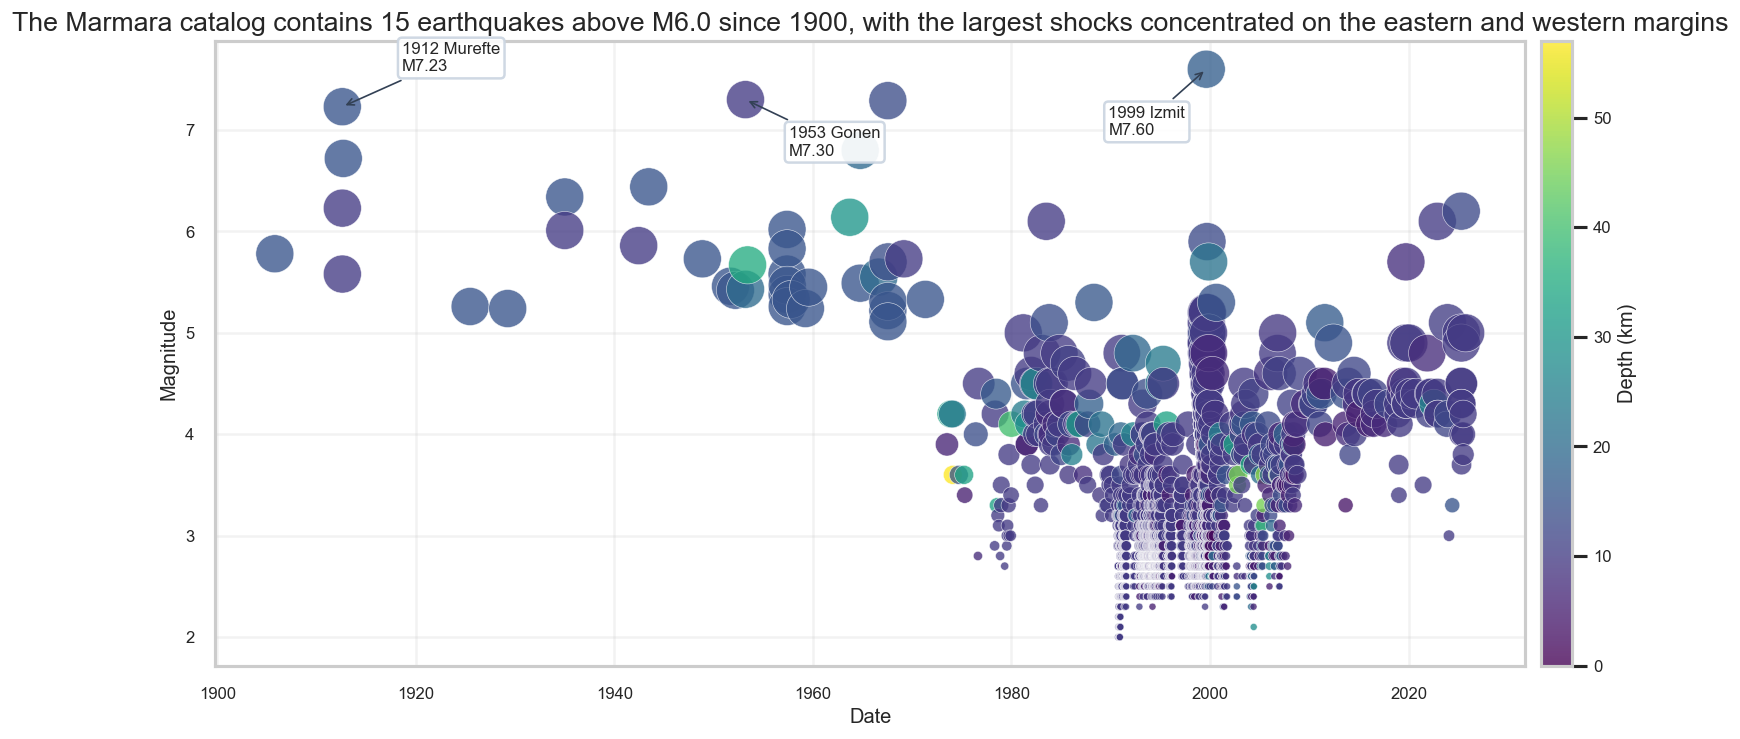

In [6]:
fig, ax = plt.subplots(figsize=(14, 6.5))
_draw_timeline(ax, earthquakes_df, add_colorbar=True)
fig.tight_layout()
plt.show()


### Deliverable 3: Magnitude-Frequency Analysis

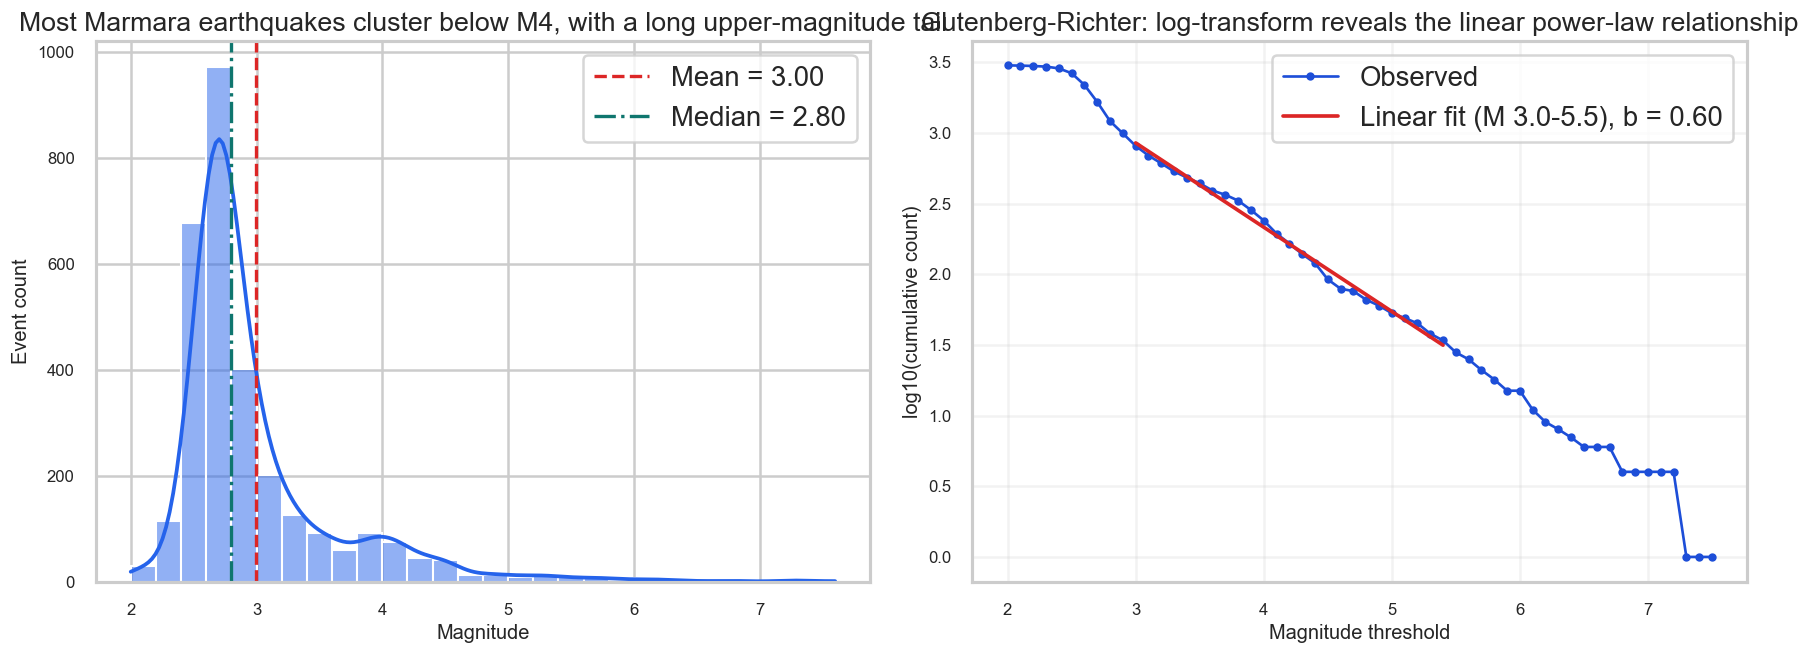

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

# Subplot 1 — Histogram + KDE
# 0.2-magnitude bins match catalog precision (0.1) while keeping the distribution readable
bins = np.arange(
    np.floor(earthquakes_df['mag'].min() * 5) / 5,
    np.ceil(earthquakes_df['mag'].max() * 5) / 5 + 0.2,
    0.2,
)
sns.histplot(earthquakes_df['mag'], bins=bins, kde=True,
             color='#2563eb', edgecolor='white', ax=axes[0])
mean_mag   = earthquakes_df['mag'].mean()
median_mag = earthquakes_df['mag'].median()
axes[0].axvline(mean_mag,   color='#dc2626', linestyle='--', linewidth=2, label=f'Mean = {mean_mag:.2f}')
axes[0].axvline(median_mag, color='#0f766e', linestyle='-.', linewidth=2, label=f'Median = {median_mag:.2f}')
axes[0].set_title('Most Marmara earthquakes cluster below M4, with a long upper-magnitude tail')
axes[0].set_xlabel('Magnitude'); axes[0].set_ylabel('Event count')
axes[0].legend(frameon=True)

# Subplot 2 — Gutenberg-Richter; linear fit on M3.0-5.5 where catalog is most complete
magnitude_bins    = np.arange(2.0, earthquakes_df['mag'].max() + 0.1, 0.1)
cumulative_counts = np.array([(earthquakes_df['mag'] >= m).sum() for m in magnitude_bins])
valid_mask = cumulative_counts > 0
mags   = magnitude_bins[valid_mask]
counts = cumulative_counts[valid_mask]
fit_mask = (mags >= 3.0) & (mags <= 5.5)
slope, intercept = np.polyfit(mags[fit_mask], np.log10(counts[fit_mask]), 1)
b_value = -slope

axes[1].plot(mags, np.log10(counts), marker='o', ms=4, lw=1.6, color='#1d4ed8', label='Observed')
axes[1].plot(mags[fit_mask], slope * mags[fit_mask] + intercept,
             color='#dc2626', linewidth=2.2, label=f'Linear fit (M 3.0-5.5), b = {b_value:.2f}')
axes[1].set_title('Gutenberg-Richter: log-transform reveals the linear power-law relationship')
axes[1].set_xlabel('Magnitude threshold'); axes[1].set_ylabel('log10(cumulative count)')
axes[1].legend(frameon=True); axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

### Deliverable 4: Building Vulnerability or Population Risk

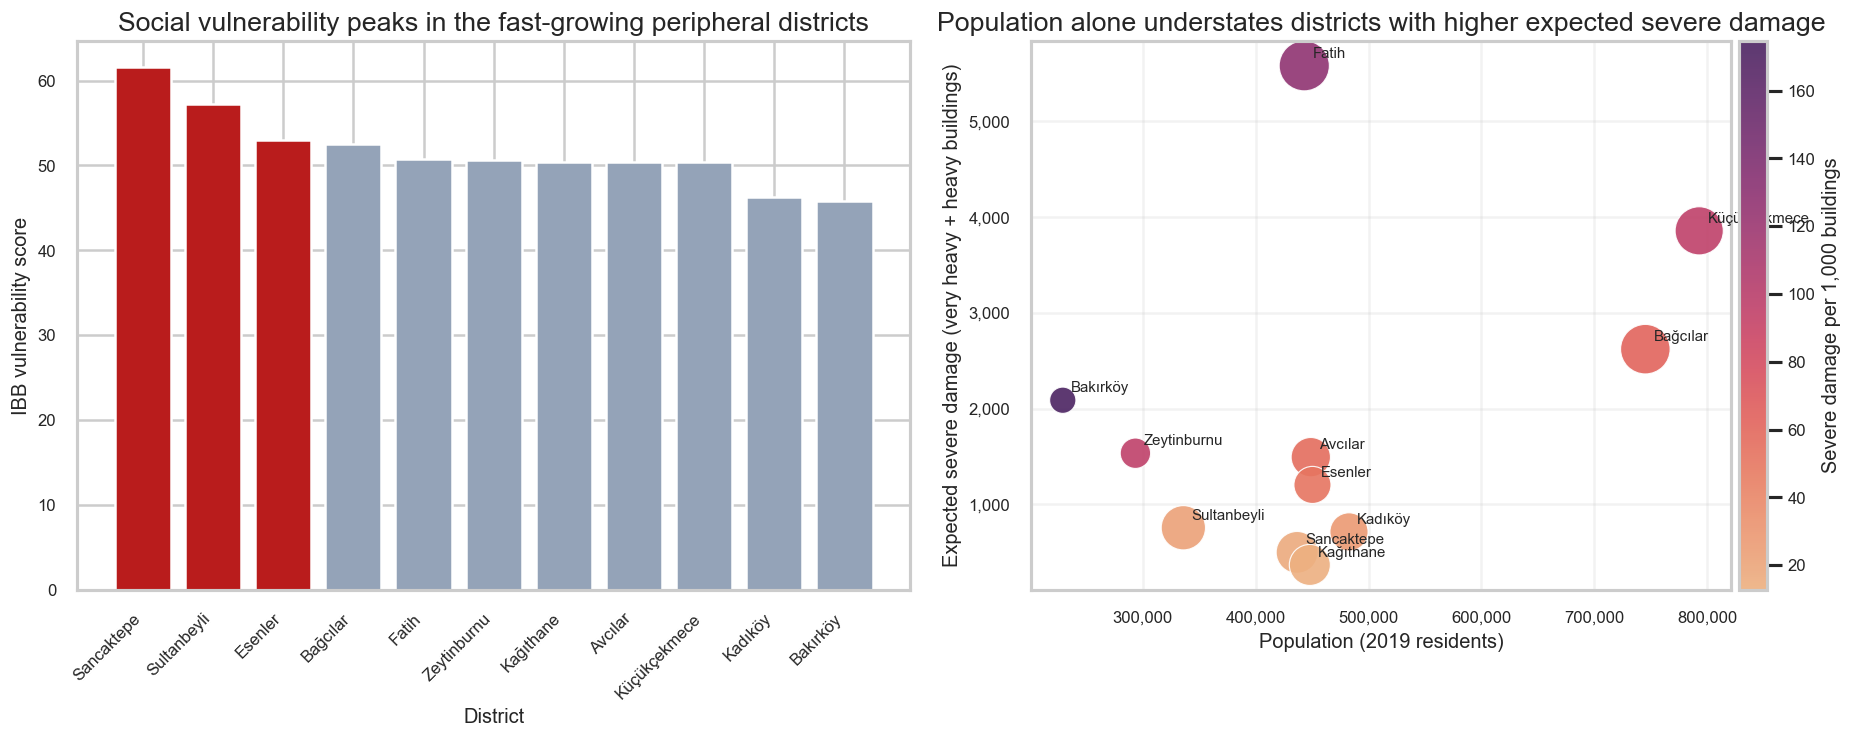

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# Subplot 1 — Vulnerability sorted descending; top 3 highlighted red
ranked    = district_df.sort_values('vulnerability_score', ascending=False).reset_index(drop=True)
highlight = set(ranked.head(3)['district'])
colors    = ['#b91c1c' if d in highlight else '#94a3b8' for d in ranked['district']]
axes[0].bar(range(len(ranked)), ranked['vulnerability_score'], color=colors)
axes[0].set_xticks(range(len(ranked)))
axes[0].set_xticklabels(ranked['district'], rotation=45, ha='right')
axes[0].set_title('Social vulnerability peaks in the fast-growing peripheral districts')
axes[0].set_xlabel('District'); axes[0].set_ylabel('IBB vulnerability score')

# Subplot 2 — Population vs. severe damage; size=total buildings, colour=damage rate/1000
scatter = axes[1].scatter(
    district_df['population'], district_df['severe_damage'],
    s=district_df['total_buildings'] / 48,
    c=district_df['damage_per_1000_buildings'],
    cmap='flare', alpha=0.9, edgecolor='white', linewidth=0.7,
)
for row in district_df.itertuples():
    axes[1].annotate(row.district, (row.population, row.severe_damage),
                     textcoords='offset points', xytext=(5, 5), fontsize=9)
cbar = fig.colorbar(scatter, ax=axes[1], pad=0.01)
cbar.set_label('Severe damage per 1,000 buildings')
axes[1].set_title('Population alone understates districts with higher expected severe damage')
axes[1].set_xlabel('Population (2019 residents)')
axes[1].set_ylabel('Expected severe damage (very heavy + heavy buildings)')
axes[1].xaxis.set_major_formatter(_comma_formatter())
axes[1].yaxis.set_major_formatter(_comma_formatter())
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

### Deliverable 5: Earthquake Hazard Visualization

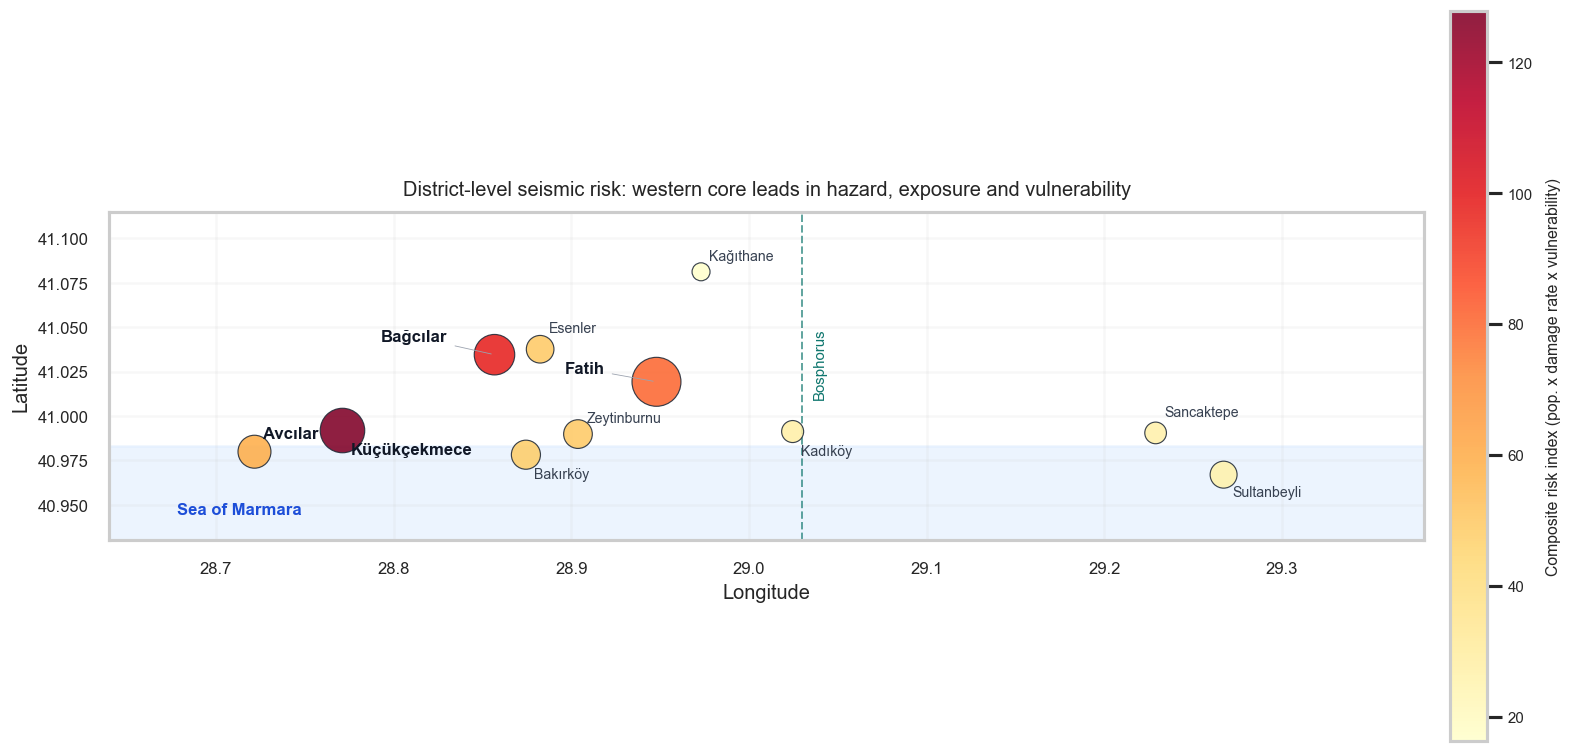

In [9]:
fig, ax = plt.subplots(figsize=(13, 7.5), constrained_layout=True)

# Bubble map: size proportional to moderate-plus damaged buildings, colour = risk index
scatter = ax.scatter(
    district_df['longitude'], district_df['latitude'],
    s=district_df['moderate_plus_damage'] / 18,
    c=district_df['risk_index'],
    cmap='YlOrRd',
    alpha=0.88,
    edgecolor='#1f2937',
    linewidth=0.7,
    zorder=3,
)

# Geographic reference layers
ax.axhspan(40.93, 40.983, color='#dbeafe', alpha=0.50, zorder=0)
ax.axvline(29.03,  color='#0f766e', linestyle='--', linewidth=1.2, alpha=0.65, zorder=1)
ax.text(28.678, 40.945, 'Sea of Marmara',  color='#1d4ed8', fontsize=10, weight='bold')
ax.text(29.036, 41.050, 'Bosphorus', color='#0f766e', fontsize=9, rotation=90, va='top')

# Per-district offsets — tuned to the western cluster geometry
# Negative dx  labels left of bubble (arrow drawn); positive dx  labels right
top_risk = set(district_df.nlargest(4, 'risk_index')['district'])
label_offsets = {
    'Avcılar':        (  5,   8),
    'Küçükçekmece':   (  5, -14),
    'Bağcılar':       (-68,   8),
    'Bakırköy':       (  5, -14),
    'Esenler':        (  5,  10),
    'Zeytinburnu':    (  5,   7),
    'Fatih':          (-55,   5),
    'Kağıthane':      (  5,   7),
    'Kadıköy':        (  5, -14),
    'Sancaktepe':     (  5,  10),
    'Sultanbeyli':    (  5, -13),
}
for row in district_df.itertuples():
    dx, dy = label_offsets.get(row.district, (5, 7))
    is_top = row.district in top_risk
    ax.annotate(
        row.district,
        xy=(row.longitude, row.latitude),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=10 if is_top else 8.5,
        weight='bold' if is_top else 'normal',
        color='#111827' if is_top else '#374151',
        arrowprops=dict(arrowstyle='-', color='#9ca3af', lw=0.5) if abs(dx) > 20 else None,
    )

# Colorbar — wide enough pad so ticks do not touch the map
cbar = fig.colorbar(scatter, ax=ax, fraction=0.028, pad=0.02, shrink=0.82)
cbar.set_label('Composite risk index (pop. x damage rate x vulnerability)',
               fontsize=9.5, labelpad=8)
cbar.ax.tick_params(labelsize=9)

ax.set_title('District-level seismic risk: western core leads in hazard, exposure and vulnerability',
             fontsize=12, pad=10)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim(28.64, 29.38)
ax.set_ylim(40.930, 41.115)
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.15)
plt.show()


### Deliverable 6: Multi-Panel Risk Dashboard + Reflection

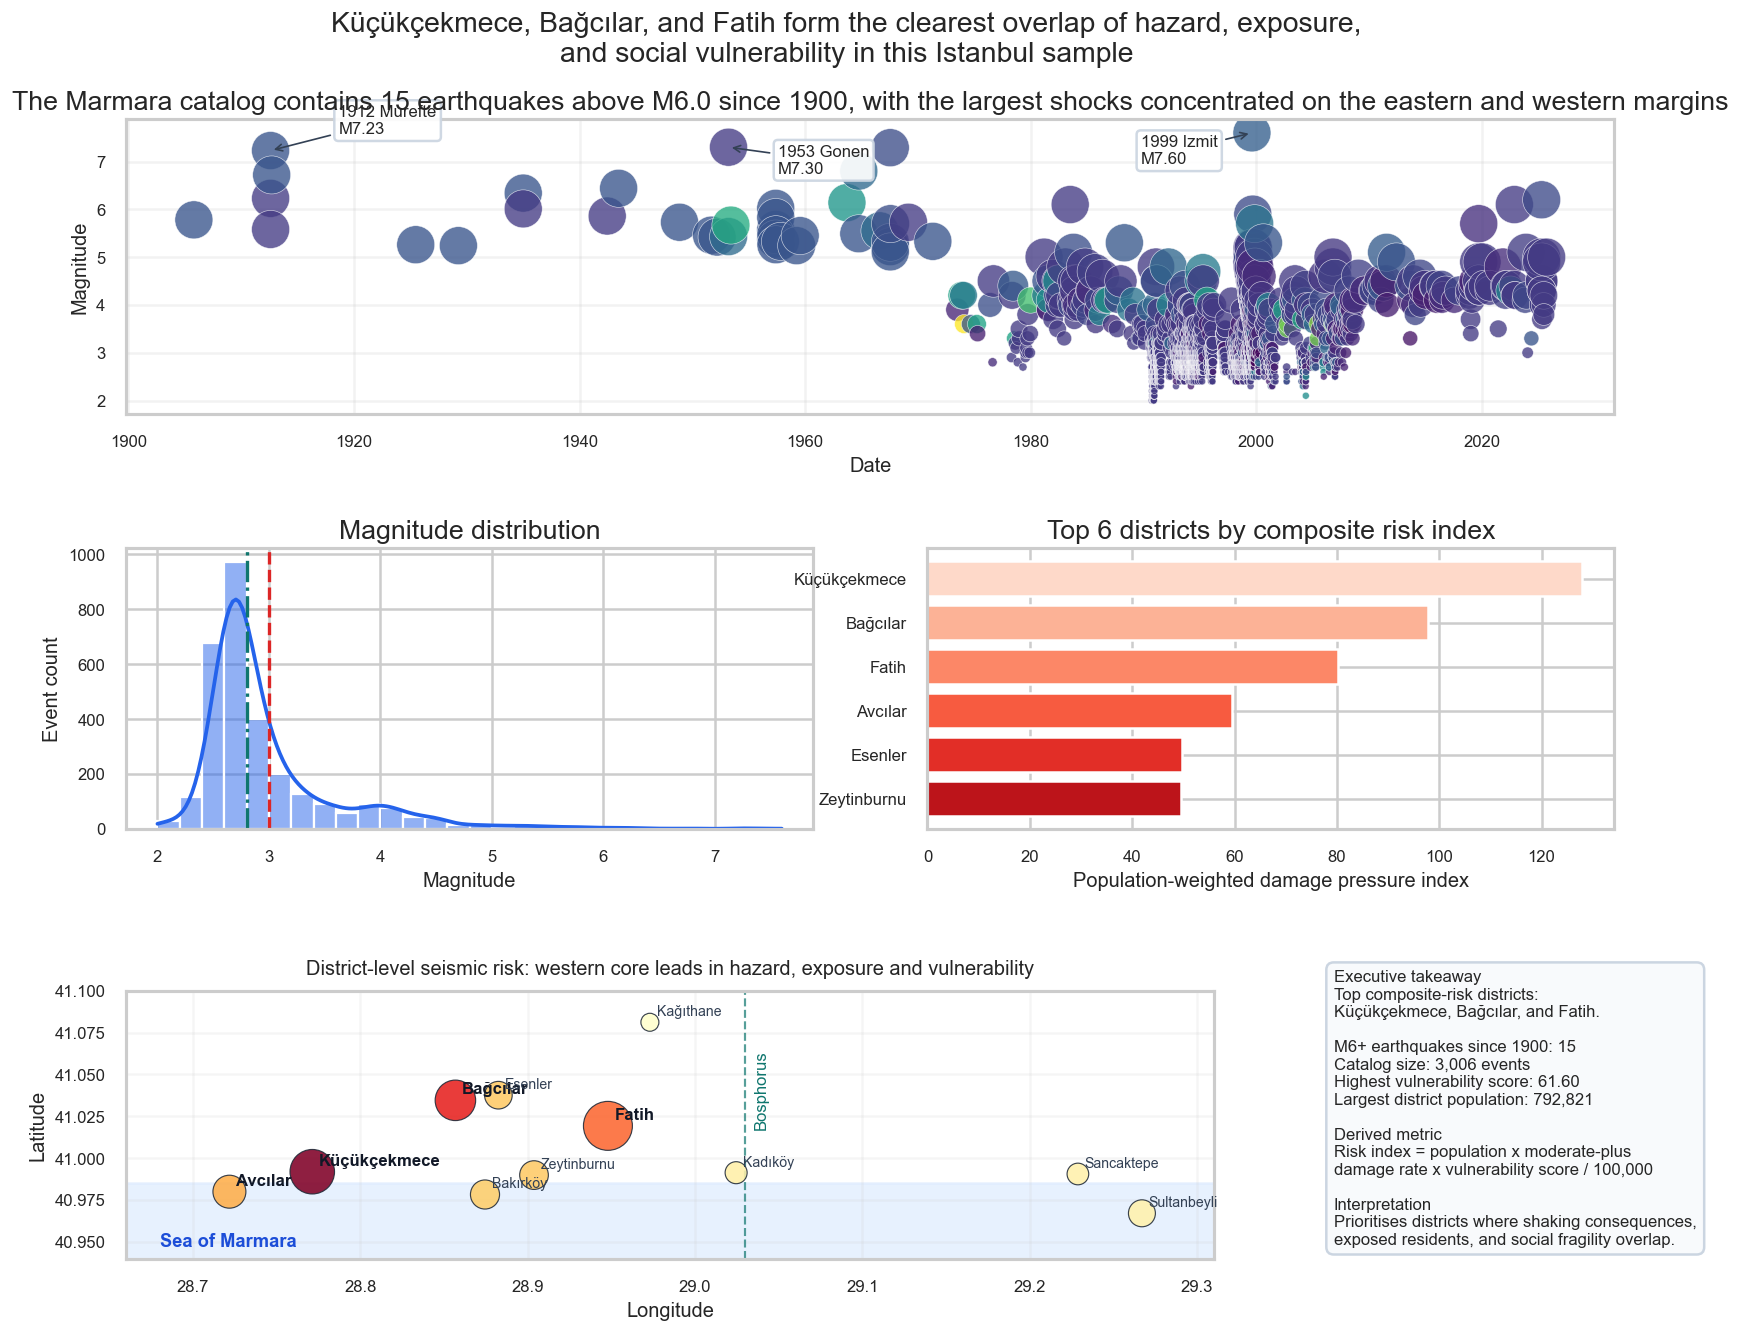

Dashboard saved -> dashboard.png


In [10]:
top3     = _top3_sentence(district_df.nlargest(3, 'risk_index')['district'])
m6_count = int((earthquakes_df['mag'] >= 6.0).sum())

fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(3, 4, height_ratios=[1.05, 1.0, 1.15], hspace=0.45, wspace=0.4)

ax_timeline = fig.add_subplot(gs[0, :])    # row 0, spans all 4 columns
ax_hist     = fig.add_subplot(gs[1, 0:2])  # row 1, left
ax_bar      = fig.add_subplot(gs[1, 2:4])  # row 1, right
ax_map      = fig.add_subplot(gs[2, 0:3])  # row 2, spans 3 columns
ax_text     = fig.add_subplot(gs[2, 3])    # row 2, rightmost col

_draw_timeline(ax_timeline, earthquakes_df, add_colorbar=False)

bins = np.arange(
    np.floor(earthquakes_df['mag'].min() * 5) / 5,
    np.ceil(earthquakes_df['mag'].max() * 5) / 5 + 0.2, 0.2,
)
sns.histplot(earthquakes_df['mag'], bins=bins, kde=True,
             color='#2563eb', edgecolor='white', ax=ax_hist)
ax_hist.axvline(earthquakes_df['mag'].mean(),   color='#dc2626', linestyle='--', linewidth=2)
ax_hist.axvline(earthquakes_df['mag'].median(), color='#0f766e', linestyle='-.', linewidth=2)
ax_hist.set_title('Magnitude distribution')
ax_hist.set_xlabel('Magnitude'); ax_hist.set_ylabel('Event count')

# Top-6 districts — use barh to avoid seaborn version compatibility issues
ranked_top = district_df.nlargest(6, 'risk_index').sort_values('risk_index')
bar_colors = plt.cm.Reds_r(np.linspace(0.2, 0.85, len(ranked_top)))
ax_bar.barh(ranked_top['district'], ranked_top['risk_index'], color=bar_colors)
ax_bar.set_title('Top 6 districts by composite risk index')
ax_bar.set_xlabel('Population-weighted damage pressure index'); ax_bar.set_ylabel('')

_draw_spatial_hazard(ax_map, district_df, add_colorbar=False)

ax_text.axis('off')
summary = (
    f"Executive takeaway\nTop composite-risk districts:\n{top3}.\n\n"
    f"M6+ earthquakes since 1900: {m6_count}\n"
    f"Catalog size: {len(earthquakes_df):,} events\n"
    f"Highest vulnerability score: {district_df['vulnerability_score'].max():.2f}\n"
    f"Largest district population: {district_df['population'].max():,}\n\n"
    "Derived metric\nRisk index = population x moderate-plus\n"
    "damage rate x vulnerability score / 100,000\n\n"
    "Interpretation\nPrioritises districts where shaking consequences,\n"
    "exposed residents, and social fragility overlap."
)
ax_text.text(0.02, 0.98, summary, va='top', ha='left', fontsize=10,
             bbox={'boxstyle': 'round,pad=0.45', 'fc': '#f8fafc', 'ec': '#cbd5e1'})

fig.suptitle(
    f"{top3} form the clearest overlap of hazard, exposure,\n"
    "and social vulnerability in this Istanbul sample",
    fontsize=17, y=0.995
)
fig.savefig('dashboard.png', dpi=300, bbox_inches='tight')
fig.subplots_adjust(top=0.92)
plt.show()
print('Dashboard saved -> dashboard.png')


#### Reflection

**1. Chart type justification (D2-D5):**

*Your answer here...*

**2. Audience adaptation (seismologists vs. municipal council):**

*Your answer here...*

**3. Self-critique (weakest visualization + improvement plan):**

*Your answer here...*

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr